In [125]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import math
import pandas as pd
import bisect
import uuid

In [126]:
import requests
import urllib
import json

def get_elevation_usgs(lon_deg, lat_deg):
    url = r'https://epqs.nationalmap.gov/v1/json?'
    params = {
        'output': 'json',
        'x': lon_deg,
        'y': lat_deg,
        'units': 'Meters'
    }
    result = requests.get((url + urllib.parse.urlencode(params)))
    return float(result.json()['value'])


def get_elevation_from_open_elevation(longitude_deg, latitude_deg):
    """
    Retrieves elevation data from the Open-Elevation API for a given
    latitude and longitude.

    Args:
        latitude (float): The latitude of the location.
        longitude (float): The longitude of the location.

    Returns:
        float or None: The elevation in meters if successful, otherwise None.
    """
    url = "https://api.open-elevation.com/api/v1/lookup"
    params = {
        "locations": f"{latitude_deg},{longitude_deg}"
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()  # Raise an exception for bad status codes (4xx or 5xx)
        data = response.json()
        
        if data and "results" in data and len(data["results"]) > 0:
            return data["results"][0]["elevation"]
        else:
            print("No elevation data found in the response.")
            return None
    except requests.exceptions.RequestException as e:
        print(f"Error making request to Open-Elevation API: {e}")
        return None
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON response: {e}")
        return None

# # Example usage:
# lat = 40.7128
# lon = -74.0060

# elevation = get_elevation_from_open_elevation(lat, lon)

# if elevation is not None:
#     print(f"The elevation at ({lat}, {lon}) is: {elevation} meters")
# else:
#     print(f"Could not retrieve elevation for ({lat}, {lon})")

In [127]:
class Location():
    def __init__(self, lon_deg: float, lat_deg: float, alt_km: float=None, name: str=""):
        self.lon_deg = lon_deg
        self.lat_deg = lat_deg
        if alt_km is None:
            alt_km = 1e-3*get_elevation_from_open_elevation(lon_deg, lat_deg)
            print("Queried OpenElevation for elevation at {}, {}: {} km".format(lon_deg, lat_deg, alt_km))
        self.alt_km = alt_km
        self.name = name
    def __str__(self):
        return "Location {} | Lon {}°, lat {}°, alt {} km".format(
            self.name,
            self.lon_deg,
            self.lat_deg,
            self.alt_km,
        )
    def __repr__(self):
        return self.__str__()

In [128]:
# Let's search for opportunities. 
# Input: a number of satellites, each with instruments. A number of ground locations we would like to image, with time windows.
# Output: a map from locations to satellite passes.

class ObservationRequest(Location):
    '''
    An observation request asks to observe a given location with a given instrument between a minimum and a maximum time.
    '''
    def __init__(self, lon_deg, lat_deg, min_time, max_time, alt_km=None, instrument="RGB", request_name=""):
        super().__init__(lon_deg=lon_deg, lat_deg=lat_deg, alt_km=alt_km, name=request_name)
        # self.name = request_name
        # self.lon_deg = lon_deg
        # self.lat_deg = lat_deg
        # self.alt_km = alt_km
        self.min_time = min_time
        self.max_time = max_time
        self.instrument = instrument
    def __str__(self):
        return "Request {} | Lon {}°, lat {}°, alt {} km from {} to {} with {}".format(
            self.name,
            self.lon_deg,
            self.lat_deg,
            self.alt_km,
            self.min_time,
            self.max_time,
            self.instrument,
        )
    def __repr__(self):
        return self.__str__()

class ObservationOpportunity(Location):
    '''
    An observation opportunity specifies a time instant when an observation request can be fulfilled 
    '''
    def __init__(self, time, lon_deg, lat_deg, alt_km, look_angle_az_deg, look_angle_dec_deg, sun_zenith_angle_deg, range_km, name="", instrument="RGB"):
        self.time = time
        super().__init__(lon_deg=lon_deg, lat_deg=lat_deg, alt_km=alt_km, name=name)
        self.instrument = instrument
        self.look_angle_az_deg = look_angle_az_deg
        self.look_angle_dec_deg = look_angle_dec_deg
        self.sun_zenith_angle_deg = sun_zenith_angle_deg
        self.range_km = range_km
    def __str__(self):
        return "Observation {} at {} with {}. Look angle {} | {} az/dec deg, zenith angle {} deg, range {} km".format(
            self.name,
            self.time,
            self.instrument,
            self.look_angle_az_deg,
            self.look_angle_dec_deg,
            self.sun_zenith_angle_deg,
            self.range_km,
        )
    def __repr__(self):
        return self.__str__()
        
class ObservationPass:
    ''' An observation pass is a time interval during which a satellite is over the horizon to a given location.
    We model it as observation opportunities for rise time, fall time, and highest time  
    '''
    def __init__(self, rise: ObservationOpportunity, fall: ObservationOpportunity, highest: ObservationOpportunity):
        self.rise = rise
        self.fall = fall
        self.highest = highest
    def __str__(self):
        return "Pass start: {}, highest: {}, fall: {}".format(self.rise.time, self.highest.time, self.fall.time)
    def __repr__(self):
        return self.__str__()

In [129]:
class Satellite():
    def __init__(self, name: str,  orbit: Orbital, instruments: list = ["RGB"], instrument_fov_rad: dict = {"RGB": 15.*np.pi/180.}):
        self.name = name
        self.orbit = orbit
        self.instruments = instruments
        self.instrument_fov_rad = instrument_fov_rad
        self.scheduled_observations = []
        self.data_products = []
        self.known_phenomena = []
    def __str__(self):
        return self.name
    def __repr__(self):
        return self.__str__()

In [130]:
def observation_quality(opportunity: ObservationOpportunity, preferred_zenith_angle_deg=45):
    '''
    A quality function that specifies how good an opportunity is
    '''
    return abs(90.-opportunity.look_angle_dec_deg)/90. + abs(preferred_zenith_angle_deg-opportunity.sun_zenith_angle_deg)/90 - opportunity.range_km/1000

In [131]:
def find_observation_opportunities(observation_requests: list, satellites: list, passes_error_s=60, passes_horizon_deg=0):
    opportunities = {}
    
    for request in observation_requests:
        opportunities[request] = {}
        for satellite in satellites:
            if request.instrument in satellite.instruments:
                orbit = satellite.orbit
                opportunities[request][satellite] = []
                _passes = orbit.get_next_passes(
                    request.min_time,
                    int(math.ceil((request.max_time-request.min_time).total_seconds()/3600)),
                    request.lon_deg,
                    request.lat_deg,
                    request.alt_km,
                    passes_error_s,
                    passes_horizon_deg
                )
                # Avoid returning a satellite if there are no passes for it
                if (len(_passes) == 0):
                    opportunities[request].pop(satellite)
                for _pass in _passes:
                    _pass_opportunities_ = []
                    for _time in _pass: # Pass has start time, end time, max alt time
                        if (_time<request.min_time or _time>request.max_time):
                            break
                            # raise ValueError("Observation opportunity {} does not fit in request {}".format(_pass,request))
                        _look_angle_az_el = orbit.get_observer_look(_time, request.lon_deg, request.lat_deg, request.alt_km)
                        _sun_zenith_angle =  pyorbital.astronomy.sun_zenith_angle(_time, request.lon_deg, request.lat_deg)
                        _range = np.linalg.norm(np.array(orbit.get_position(_time, normalize=False)[:3])-np.array(pyorbital.astronomy.observer_position(_time, request.lon_deg, request.lat_deg, request.alt_km)[:3]))
                        # print(_range)
                        _opp = ObservationOpportunity(
                            time=_time,
                            lon_deg = request.lon_deg,
                            lat_deg = request.lat_deg,
                            alt_km = request.alt_km,
                            look_angle_az_deg=_look_angle_az_el[0],
                            look_angle_dec_deg=_look_angle_az_el[1],
                            sun_zenith_angle_deg=_sun_zenith_angle,
                            range_km=_range,
                        )
                        _pass_opportunities_.append(_opp)
                    if (len(_pass_opportunities_)==3):
                        opportunities[request][satellite].append(ObservationPass(
                            rise=_pass_opportunities_[0],
                            fall=_pass_opportunities_[1],
                            highest=_pass_opportunities_[2],
                        ))
                    
    return opportunities

In [132]:
def find_contact_opportunities(ground_stations: list, satellites: list, min_time: dt.datetime, max_time: dt.datetime, passes_error_s=60, passes_horizon_deg=15):
    
    ground_station_opportunities = [
        ObservationRequest(
            lon_deg=gs.lon_deg,
            lat_deg=gs.lat_deg,
            alt_km=gs.alt_km,
            min_time=min_time,
            max_time=max_time,
            request_name=gs.name,
        )
        for gs in ground_stations
    ]

    gs_opportunity_decoder = {
        gs.name: gs for gs in ground_stations
    }

    comm_opportunities_by_ground_station = find_observation_opportunities(
        observation_requests=ground_station_opportunities,
        satellites=satellites,
        passes_error_s=passes_error_s,
        passes_horizon_deg=passes_horizon_deg
    )

    # Now this is a list of opportunity (GS+time)->satellite->pass.
    # What we want is satellite->station->pass, or satellite->(station, pass).
    comm_opportunities_by_satellite_and_station = {}
    comm_opportunities_by_satellite = {}
    
    for gs_req, satpasses in comm_opportunities_by_ground_station.items():
        for sat, satpass in satpasses.items():
            
            if sat not in comm_opportunities_by_satellite_and_station.keys():
                comm_opportunities_by_satellite_and_station[sat] = {}
            if sat not in comm_opportunities_by_satellite.keys():
                comm_opportunities_by_satellite[sat] = []
            gs = gs_opportunity_decoder[gs_req.name]
            
            if gs not in comm_opportunities_by_satellite_and_station[sat]:
                comm_opportunities_by_satellite_and_station[sat][gs] = []    
            # Satpass is a LIST of opportunities for this given ground station and satellite.
            comm_opportunities_by_satellite_and_station[sat][gs].extend(satpass)
            for _pass in satpass:
                comm_opportunities_by_satellite[sat].append((gs, _pass))
            
    for sat, passes in comm_opportunities_by_satellite.items():
        passes.sort(key=lambda x: x[1].highest.time)
        
    for sat, stationpasses in comm_opportunities_by_satellite_and_station.items():
        for station, passes in stationpasses.items():
            passes.sort(key=lambda x: x.highest.time)
    
    return comm_opportunities_by_satellite_and_station, comm_opportunities_by_satellite

In [133]:
# # Behind the scenes, this pulls from Celestrak if we do not specify tle_file

# satellites = {
#     "LOFT YAM-3": Orbital("YAM-3", tle_file="TLEs.txt"),
#     "LOFT YAM-5": Orbital("YAM-5", tle_file="TLEs.txt"),
#     "LOFT YAM-6": Orbital("YAM-6", tle_file="TLEs.txt"),
#     "LOFT YAM-7": Orbital("YAM-7", tle_file="TLEs.txt"),
#     "LOFT YAM-8": Orbital("YAM-8", tle_file="TLEs.txt"),
#     "LOFT YAM-10": Orbital("YAM-10", tle_file="TLEs.txt"),
#     "Ubotica CogniSat-6 HAMMER": Orbital("HAMMER", tle_file="TLEs.txt"),
#     # "LOFT YAM-3": Orbital("YAM-3"),
# }

In [134]:
# Behind the scenes, this pulls from Celestrak if we do not specify tle_file

satellites = [
    Satellite("LOFT YAM-3", Orbital("YAM-3", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-5", Orbital("YAM-5", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-7", Orbital("YAM-7", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-8", Orbital("YAM-8", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    # "LOFT YAM-3": Orbital("YAM-3"),
]

In [135]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

# ground_station_opportunities = [
#     observation_request(
#         lon_deg=gs.lon_deg,
#         lat_deg=gs.lat_deg,
#         alt_km=gs.alt_km,
#         min_time=dt.datetime.now(dt.timezone.utc),
#         max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)
#     )
#     for gs in ground_stations
# ]

In [136]:
comm_opportunities_by_sat_and_station, comm_opportunities_by_sat = find_contact_opportunities(
    ground_stations=ground_stations,
    satellites=satellites,
    min_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
    max_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)+dt.timedelta(seconds=3600*24*2),
    passes_error_s=60,
    passes_horizon_deg=20
)

In [137]:
stride_s = 60
plot_range_s = 10800

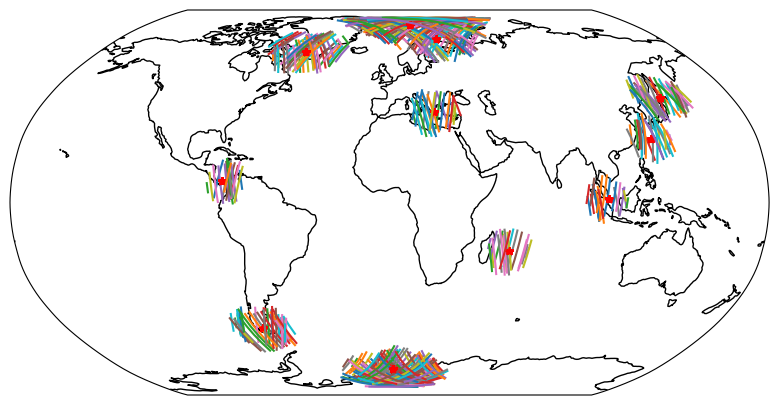

In [138]:
# comm_opportunities_by_sat

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

# fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

ground_station_dict = {gs.name: gs for gs in ground_stations}

for satellite, sat_passes_with_gs in comm_opportunities_by_sat.items():
    for (ground_station, satpass) in sat_passes_with_gs:
        # ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
        # ax.coastlines()
    
        # request location
        # ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
        # ground_station = ground_station_dict[gs]
        axglobal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    
        # Where is the satellite?
    
        _dt = dt.timedelta(seconds=stride_s)
        time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]
    
        _orbit = satellite.orbit
        _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
        # ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
        axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
    
        # Where is the satellite looking?
        # _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
        # axglobal.plot(
        #     [float(orequest.lon_deg), _highest_lla[0]],
        #     [float(orequest.lat_deg), _highest_lla[1]],
        #     ':k',
        #     transform=ccrs.Geodetic()
        # )
        
        # ax.plot(
        #     [float(orequest.lon_deg), _highest_lla[0]],
        #     [float(orequest.lat_deg), _highest_lla[1]],
        #     ':k',
        #     transform=ccrs.Geodetic()
        # )
        
        # request_counter += 1

In [139]:
ground_stations

[Location KSAT Panama | Lon -79.55°, lat 8.9833°, alt 0.028 km,
 Location KSAT Nuuk | Lon -51.73363°, lat 64.182789°, alt 0 km,
 Location KSAT Troll | Lon 2.53219°, lat -72.01243°, alt 0 km,
 Location KSAT Hokkaido | Lon 142.3689°, lat 43.8°, alt 0 km,
 Location KSAT Singapore | Lon 103.9915°, lat 1.3661°, alt 0 km,
 Location KSAT Punta Arenas | Lon -70.85021°, lat -52.93279°, alt 0 km,
 Location KSAT Okinawa | Lon 127.7766°, lat 26.4055°, alt 0 km,
 Location KSAT Mauritius | Lon 57.5565°, lat -20.1142°, alt 0 km,
 Location KSAT Nemea | Lon 22.62216°, lat 37.84604°, alt 0 km,
 Location KSAT Vardo | Lon 31.12509°, lat 70.36779°, alt 0 km,
 Location KSAT Svalbard | Lon 15.39964°, lat 78.22875°, alt 0 km]

In [140]:
# yam3.get_position(now)
# yam3.get_lonlatalt(now)
# yam3.get_next_passes(now,12,-118,33,0,60,0)

In [141]:
# Copyright 2025 frossi
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#     https://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.



In [142]:
# The first thing you do with a new batch of satellites: plot ground tracks. The simple way.



time_steps_for_plotting = [dt.datetime.now(dt.timezone.utc).replace(tzinfo=None) + dt.timedelta(seconds=stride_s*i) for i in range(int(plot_range_s/stride_s))]

llas = {}
for satellite in satellites:
    llas[satellite] = [satellite.orbit.get_lonlatalt(t) for t in time_steps_for_plotting]


In [143]:
# map = Basemap(projection='robin',lon_0=0,resolution='c')
# map.drawcoastlines()

# for satellite in llas:
#     map.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]], '.', latlon=True)

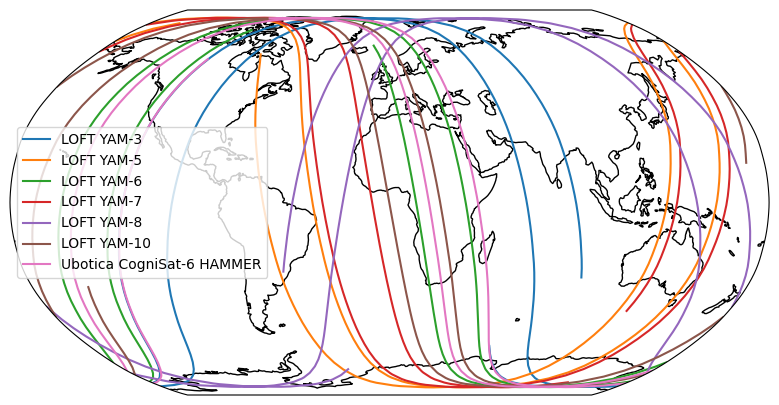

In [144]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

    # ax.stock_img()
ax.coastlines()
for satellite in llas:
    ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite.name)
ax.legend()

In [145]:
jpl_lla = [-118.1730155, 34.2009478, 0.329]
passes_horizon_h = 12
passes_error_s = 60
passes_horizon_deg = 0.

passes = {}

for satellite in satellites:
    passes[satellite] = satellite.orbit.get_next_passes(dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),passes_horizon_h,jpl_lla[0],jpl_lla[1],jpl_lla[2],passes_error_s,passes_horizon_deg)

In [146]:
for satellite, passlist in passes.items():
    if len(passlist):
        print("{} passes for {}".format(len(passlist), satellite.name))
        for satpass in passlist:
            print("Start: {}. End: {}. Max altitude: {}".format(satpass[0], satpass[1], satpass[2]))
    else:
        print("No passes for {}".format(satellite.name))

3 passes for LOFT YAM-3
Start: 2025-11-12 23:35:51.369594. End: 2025-11-12 23:40:55.593242. Max altitude: 2025-11-12 23:38:23.567863
Start: 2025-11-13 01:05:55.281484. End: 2025-11-13 01:16:35.017859. Max altitude: 2025-11-13 01:11:08.529483
Start: 2025-11-13 02:40:46.327040. End: 2025-11-13 02:45:15.172189. Max altitude: 2025-11-13 02:43:00.714762
3 passes for LOFT YAM-5
Start: 2025-11-13 03:18:26.929274. End: 2025-11-13 03:20:04.911439. Max altitude: 2025-11-13 03:19:15.897880
Start: 2025-11-13 04:45:56.219522. End: 2025-11-13 04:56:53.650634. Max altitude: 2025-11-13 04:51:20.842312
Start: 2025-11-13 06:20:57.885728. End: 2025-11-13 06:28:27.722222. Max altitude: 2025-11-13 06:24:42.564506
2 passes for LOFT YAM-6
Start: 2025-11-12 22:57:23.573419. End: 2025-11-12 23:08:09.658821. Max altitude: 2025-11-12 23:02:50.335457
Start: 2025-11-13 09:27:06.471893. End: 2025-11-13 09:37:54.849007. Max altitude: 2025-11-13 09:32:28.069407
2 passes for LOFT YAM-7
Start: 2025-11-13 05:38:51.31617

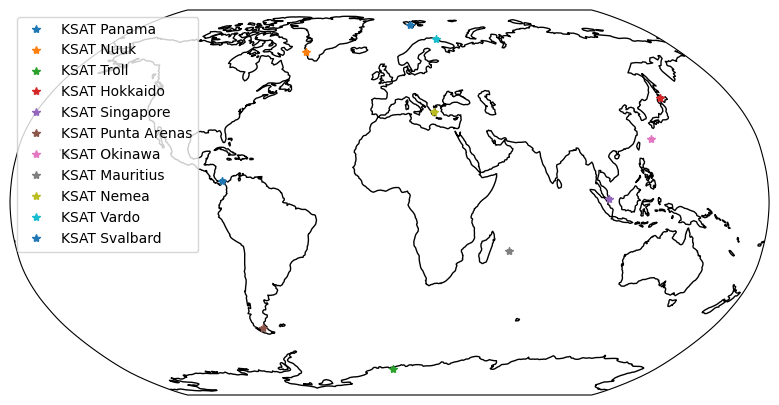

In [147]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

    # ax.stock_img()
ax.coastlines()
for station in ground_stations:
    ax.plot(station.lon_deg, station.lat_deg,'*',transform=ccrs.Geodetic(), label=station.name)
ax.legend()

In [148]:
print(get_elevation_usgs(-118,34))
print(get_elevation_from_open_elevation(-118,34))

295.55368042
307.0


In [149]:
min_time = dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)
max_time = min_time + dt.timedelta(hours=24)

os = ObservationRequest(-118,34, alt_km=0.307, min_time=min_time, max_time=max_time)

In [150]:
obs_requests = [
    ObservationRequest(-118., 34., min_time=min_time, max_time=max_time, alt_km=0.307),
    ObservationRequest(8., 45., min_time=min_time, max_time=max_time, alt_km=0.216),
    ObservationRequest(-80., 34., min_time=min_time, max_time=max_time, alt_km=0.041),
]

In [151]:
observation_opportunities = find_observation_opportunities(obs_requests, satellites)

In [152]:
# for request, passes in observation_opportunities.items():
#     for satellite, satpasses in passes.items():
#         for satpass in satpasses:
#             print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))

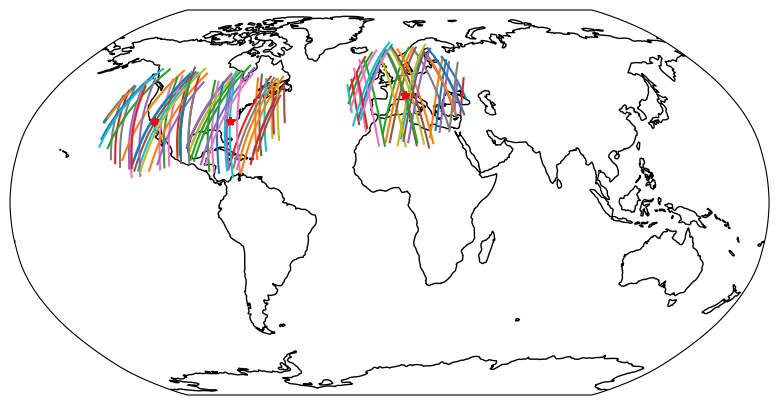

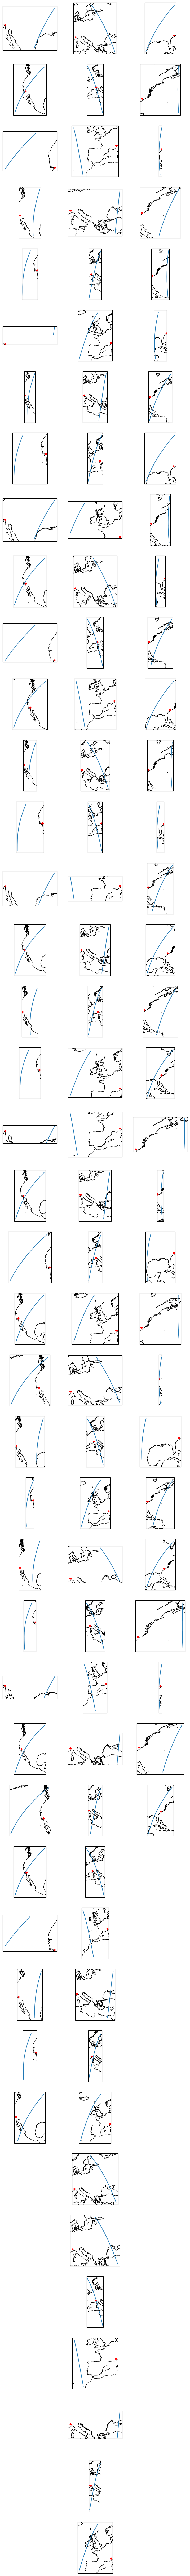

In [153]:
_plot_offset_deg = 20

request_counter = 1
pass_counter = 0

request_number = len(observation_opportunities)
max_num_passes = max([sum([len(passes) for passes in all_passes.values()]) for all_passes in observation_opportunities.values()])

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(3*request_number, 3*max_num_passes))

for orequest, all_passes in observation_opportunities.items():
    pass_counter = 0
    for satellite, passes in all_passes.items():
        for satpass in passes:
            ax = fig.add_subplot(max_num_passes, request_number, request_counter + request_number*pass_counter, projection=ccrs.Robinson())
            pass_counter += 1
            # ax.set_global()
            # ax.set_extent((float(orequest.lon_deg)-_plot_offset_deg, float(orequest.lon_deg)+_plot_offset_deg, float(orequest.lat_deg)-_plot_offset_deg, float(orequest.lat_deg)+_plot_offset_deg))
            ax.coastlines()
        
            # request location
            ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
            axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

            # Where is the satellite?

            _dt = dt.timedelta(seconds=stride_s)
            time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

            # for satellite, orbit in satellites.items():
            _orbit = satellite.orbit
            _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
            ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
            axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

#             # for satellite in llas:
#             #     ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite)
#             # ax.legend()
    request_counter += 1

## Pick the best request. Greeedy, no conflicts or anything

In [154]:
best_request = {r: None for r in obs_requests}

for request, passes in observation_opportunities.items():
    _best_quality = - np.inf
    _best_satellite = None
    _best_pass = None
    for satellite, satpasses in passes.items():
        for satpass in satpasses:
            _quality = observation_quality(satpass.highest)
            if _quality >= _best_quality:
                _best_quality = _quality
                _best_satellite = satellite
                _best_pass = satpass
            # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
    best_request[request] = (_best_satellite, _best_pass)

In [155]:
best_request

{Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB: (LOFT YAM-6,
  Pass start: 2025-11-13 09:27:02.605509, highest: 2025-11-13 09:32:22.766609, fall: 2025-11-13 09:37:51.552902),
 Request  | Lon 8.0°, lat 45.0°, alt 0.216 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB: (LOFT YAM-8,
  Pass start: 2025-11-13 22:06:10.912946, highest: 2025-11-13 22:12:06.102856, fall: 2025-11-13 22:17:59.713164),
 Request  | Lon -80.0°, lat 34.0°, alt 0.041 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB: (LOFT YAM-7,
  Pass start: 2025-11-13 04:03:41.967003, highest: 2025-11-13 04:09:07.078079, fall: 2025-11-13 04:14:38.772471)}

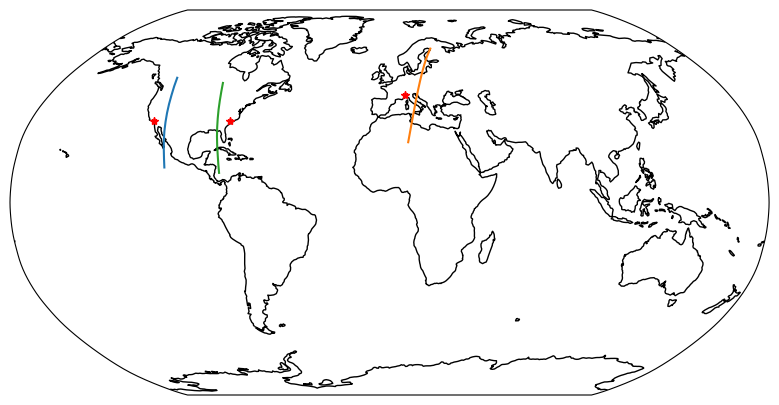

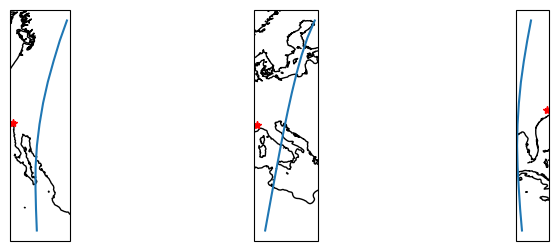

In [156]:
_plot_offset_deg = 20

request_counter = 1

request_number = len(observation_opportunities)

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(3*request_number, 3))

for orequest, (satellite, satpass) in best_request.items():
    ax = fig.add_subplot(1, request_number, request_counter, projection=ccrs.Robinson())
    ax.coastlines()

    # request location
    ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    # Where is the satellite?

    _dt = dt.timedelta(seconds=stride_s)
    time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

    # for satellite, orbit in satellites.items():
    _orbit = satellite.orbit
    _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
    ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
    axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

#             # for satellite in llas:
#             #     ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite)
#             # ax.legend()
    request_counter += 1

For a given set of requests:
- [X] List all the requests. This is what the "most-likely-won't-get-the-observation" policy should request;
- [X] Compute sun angle, view angle, range (for a quality metric)
- [X] Pick the best observation for every opportunity
- [ ] Identify conflicts between observations (slewing time)
- [ ] Pick the best observation for every opportunity with a ILP accounting for conflicts. This is the "I-will-get-every-request" solution.
- [ ] Formulate a MDP with states, actions, transitions, etc.

# More locations

Read a DB of world cities. Generate a good number of locations.

In [157]:
cities_of_the_world = pd.read_csv("simplemaps_worldcities_basicv1.901/worldcities.csv")

In [158]:
sampled_world_cities = cities_of_the_world.sample(n=100,weights='population',axis=0, random_state=0)

In [159]:
one_hundred_sampled_cities = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities.iterrows()
]

In [160]:
# one_hundred_sampled_cities

In [161]:
observation_opportunities_cities = find_observation_opportunities(one_hundred_sampled_cities, satellites)

In [162]:
best_request_cities = {r: None for r in one_hundred_sampled_cities}

for request, passes in observation_opportunities_cities.items():
    _best_quality = - np.inf
    _best_satellite = None
    _best_pass = None
    for satellite, satpasses in passes.items():
        for satpass in satpasses:
            _quality = observation_quality(satpass.highest)
            if _quality >= _best_quality:
                _best_quality = _quality
                _best_satellite = satellite
                _best_pass = satpass
            # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
    best_request_cities[request] = (_best_satellite, _best_pass)

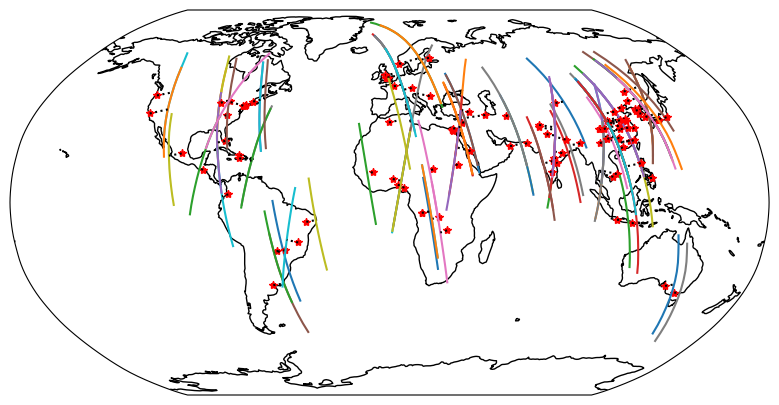

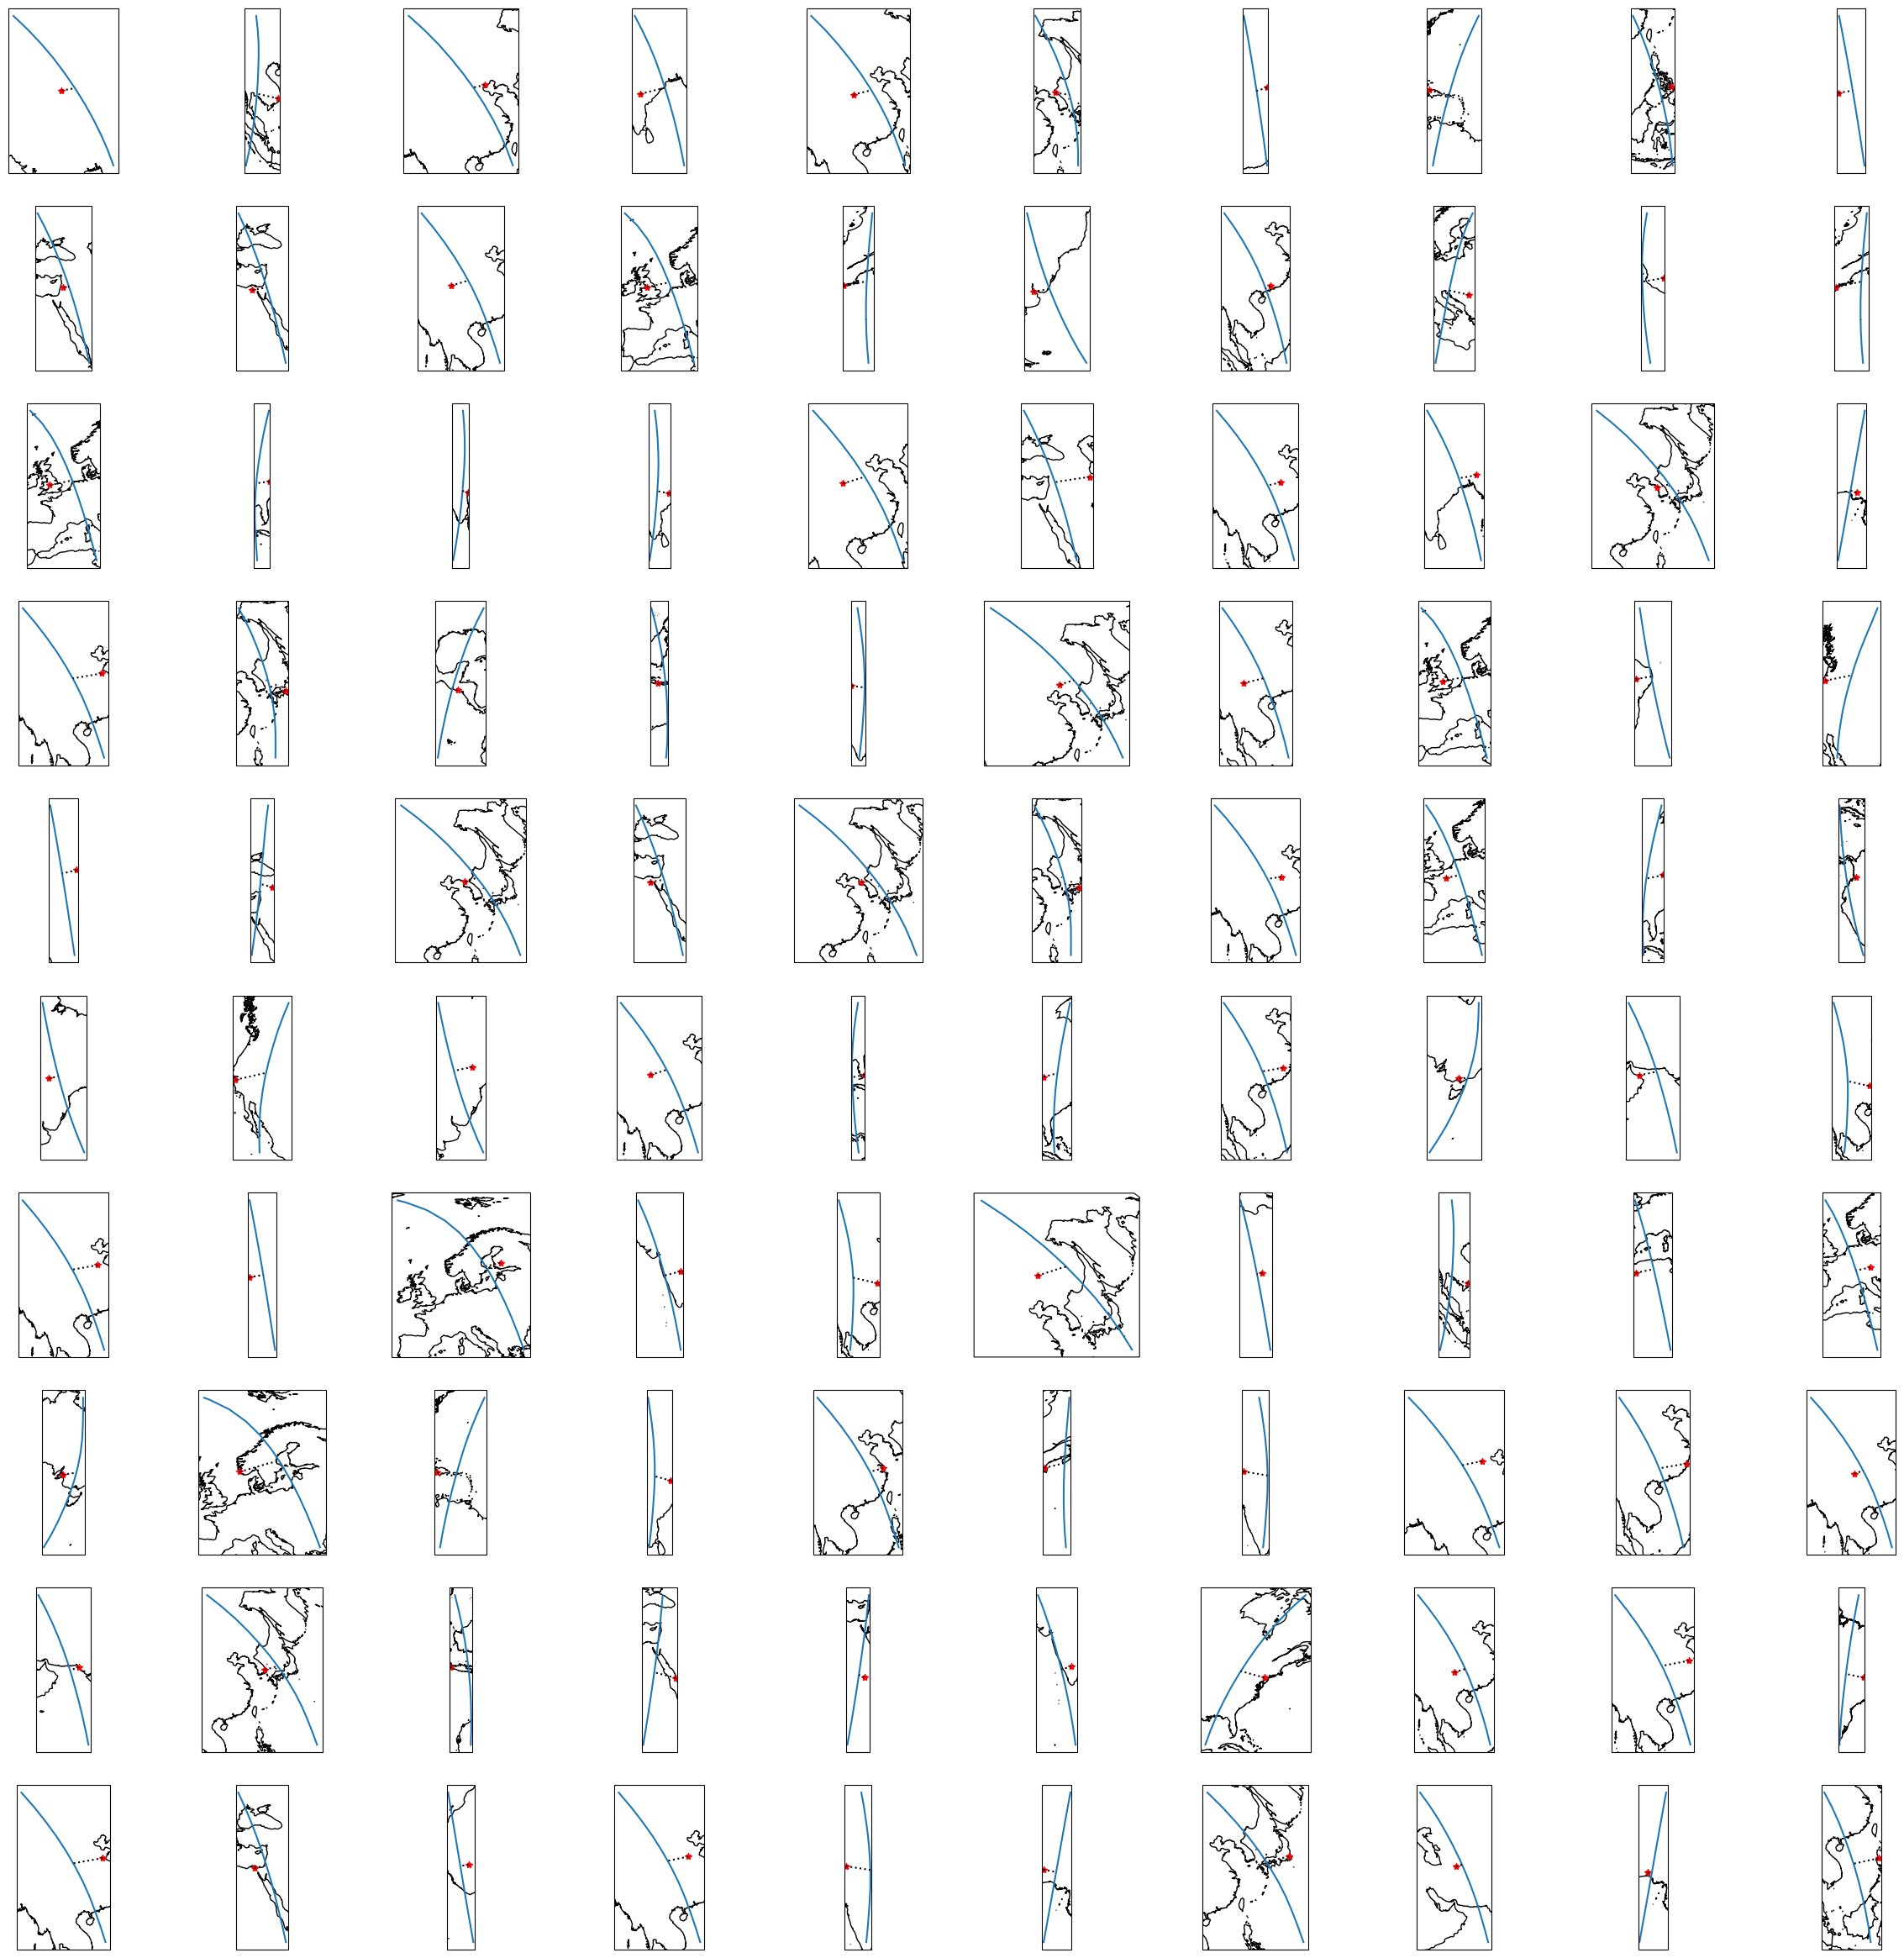

In [163]:
_plot_offset_deg = 20

request_counter = 1

request_number = len(observation_opportunities_cities)

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

for orequest, (satellite, satpass) in best_request_cities.items():
    ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
    ax.coastlines()

    # request location
    ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    # Where is the satellite?

    _dt = dt.timedelta(seconds=stride_s)
    time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

    _orbit = satellite.orbit
    _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
    ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
    axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

    # Where is the satellite looking?
    _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
    axglobal.plot(
        [float(orequest.lon_deg), _highest_lla[0]],
        [float(orequest.lat_deg), _highest_lla[1]],
        ':k',
        transform=ccrs.Geodetic()
    )
    ax.plot(
        [float(orequest.lon_deg), _highest_lla[0]],
        [float(orequest.lat_deg), _highest_lla[1]],
        ':k',
        transform=ccrs.Geodetic()
    )
    
    request_counter += 1

# Simulation

Let's talk about simulation.

We want an event-based sim. There is a global ordered timeline and the sim jumps from event to event.

Continuous transitions (power, thermal, etc) are discretized in this setting.

We need a few entities here.

Agent: a satellite, a constellation manager, a requestor. 

Event: something on the ground turning on or off.

Communication: something that affects the state of two entities.

Observation: a query of an agent to (event, empty set). If we want to be fancy, a query of an agent to a region, where events are or are 
not associated with regions.

Prototype:
- A Satellite class with a list of Observations
- A ConstellationManager class with a list of Satellites which can query Observations and add new ones.
  - A ConstellationManager class that updates the Satellites' Observations when a Communication event occurs.
- An Observation of a Region.
    - Observe. Returns an image of the region.
    - Search. Returns True if there is an Event in the Region. The event is stored.
    - Monitor. Returns True if the event is still active.
    - Something for moving events?
- Phenomenon: something with a spatial position, start time, end time, potentially internal states.

The simulator holds:
- Agents (Satellites, ConstellationManagers)
- Phenomena.
- A list of Events (Observation, Communication, Phenomenon transitions), encoded as functions.
The output of the functions affects the agents and phenomena.

We need to define:

- An Observation Opportunity (observation_opportunity)
- An Observer, which has an Orbit, a list of Observation Opportunities to execute, a list of ObservedEvents it has observed (with their state), and a list of DataProducts.
- A ConstellationManager, which has a list of ObserverStates (Orbit, ObservationOpportunities) and a list of CommunicationOpportunities with Observers. When there is a CommunicationOpportunity the ConstellationManager can push an updated list of ObservationOpportunities.
- An Event, with a lonlatalt, a State (enum), and times for StateTransitions.
- 

In [164]:
MIN_HORIZON_ANGLE_FOR_PASS_DEG = 15
MIN_HORIZON_ANGLE_FOR_OBS_DEG = 15

class Event():
    def __init__(self, time: dt.datetime, action_callable, name: str="", id: str=None):
        self.time = time
        self.action_callable = action_callable
        self.name = name
        if id is None:
            id = uuid.uuid4()
        self.id = id
    def __str__(self):
        return "Event {} at {}".format(self.name, self.time)
    def __repr__(self):
        return self.__str__()

# class Satellite():
# defined above

class Phenomenon(Location):
    def __init__(self, lon_deg: float, lat_deg: float, alt_km: float, start_time: dt.datetime, end_time: dt.datetime, name: str=""):
        super().__init__(lon_deg=lon_deg, lat_deg=lat_deg, alt_km=alt_km, name=name)
        # self.lon_deg = lon_deg
        # self.lat_deg = lat_deg
        # self.alt_km = alt_km
        self.start_time = start_time
        self.end_time = end_time
        # self.name = name
    def __str__(self):
        return "{}: Lon {}, lat {}, alt {}, start {}, end {}".format(self.name, self.lon_deg,self.lat_deg,self.alt_km, self.start_time, self.end_time)
    def __repr__(self):
        return self.__str__()

   
class World():
    def __init__(self, agents: list=[], phenomena: list = [], events: list = []):
        self.agents = agents
        self.phenomena = phenomena
        self.events = events
        self.time = dt.datetime.min
    
    def tick(self, print_forbidden_prefixes=[]):
        if len(self.events):
            _event = self.events.pop(0)
            _print_event_name = True
            for forbidden_names in print_forbidden_prefixes:
                if _event.name.startswith(forbidden_names):
                    _print_event_name = False
                    break
            if _print_event_name:
                print("Executing {}".format(_event))
            outcome = _event.action_callable()
            self.time = _event.time
            
        else:
            print("No more events")
            pass
        return len(self.events)

    def add_agent(self, agent):
        self.agents.append(agent)
    
    def add_event(self, event):
        # print("Adding {}".format(event))
        if (event.time<self.time):
            raise ValueError("Event {} is earlier than sim time {}".format(event, self.time)) 
        bisect.insort(self.events, event, key=lambda x: x.time)
        
    def do_observation(self, observation: ObservationOpportunity, spacecraft: Satellite):
        # Find phenomena close to the observation location in space and at the right time
        # Return a data product and a list of event states
        # print("Obs opp {}".format(observation))
        observed_phenomena = []

        # Now let's see what we observed
        for _phenomenon in self.phenomena:
            if (_phenomenon.start_time <= observation.time and _phenomenon.end_time > observation.time):
                # print("Candidate phenomenon {}".format(_phenomenon))
                
                # Compute phenomenon location on the planet
                _ph_location_ecf = np.array(pyorbital.astronomy.observer_position(observation.time, _phenomenon.lon_deg, _phenomenon.lat_deg, _phenomenon.alt_km)[0][:3])
                        # print(np.array(orbit.get_position(_time, normalize=False)))
                # print("Ph location {}".format(_ph_location_ecf))
                # Compute observation location on the planet
                _obs_location_ecf = np.array(pyorbital.astronomy.observer_position(observation.time, observation.lon_deg, observation.lat_deg, observation.alt_km)[0][:3])
                # print("Obs location {}".format(_obs_location_ecf))
                # Compute SC location
                _sc_location_ecf = np.array(spacecraft.orbit.get_position(observation.time, normalize=False)[0][:3])
                # print("Sc location {}".format(_sc_location_ecf))
                # Compute angle between sc-observation and sc-phenomenon
                _ph_sc_vector = _ph_location_ecf-_sc_location_ecf
                _obs_sc_vector = _obs_location_ecf - _sc_location_ecf
                # print("PhSc {} || ObsSc {}".format(_ph_sc_vector, _obs_sc_vector))
                # print("Dot: {} || N1: {} N2: {}".format(np.dot(_ph_sc_vector,_obs_sc_vector),np.linalg.norm(_ph_sc_vector,2), np.linalg.norm(_obs_sc_vector,2))) 
                # print("Acos: {}, angle: {}".format(np.dot(_ph_sc_vector,_obs_sc_vector)/(np.linalg.norm(_ph_sc_vector,2)*np.linalg.norm(_obs_sc_vector,2)), np.arccos(np.dot(_ph_sc_vector,_obs_sc_vector)/(np.linalg.norm(_ph_sc_vector,2)*np.linalg.norm(_obs_sc_vector,2)))))
                _ph_obs_angle_rad = np.arccos(np.clip(np.dot(_ph_sc_vector,_obs_sc_vector)/(np.linalg.norm(_ph_sc_vector,2)*np.linalg.norm(_obs_sc_vector,2)),-1,1))
                # print("Obs angle (rad) {}".format(_ph_obs_angle_rad))
                # If angle<FOV, return phobservation
                if _ph_obs_angle_rad < spacecraft.instrument_fov_rad[observation.instrument]:
                    # print("Close enough")
                    observed_phenomena.append(_phenomenon)
                else:
                    # print("Too far")
                    pass
        # Store SOMETHING for the completed observation
        spacecraft.data_products.append(observation)
        spacecraft.known_phenomena.append(observed_phenomena)
        
        return True
        







In [ ]:
def do_downlink(spacecraft: Satellite, scheduler, comm_pass: ObservationPass): # scheduler is a ConstellationGroundScheduler,defined next 
    # Simple: downlink all. Future: downlink up to x.
    
    # Duration is unused for now
    duration = comm_pass.fall.time - comm_pass.rise.time

    _downlinked = []
    if len(spacecraft.data_products):
        print("Spacecraft {} has {} data products to download".format(spacecraft, len(spacecraft.data_products)))
        
    for data_product in spacecraft.data_products:
        print("  Downlinked {}".format(data_product))
        _downlinked.append(data_product)

        # found_the_requestor = False
        # for _req, _reqdata in scheduler.requests.items():
        #     if data_product == _reqdata['observation']:
        #         _reqdata['status'] = "OK! Data received"
        #         _reqdata['data_product'] = data_product
        #         # This lets the caller know
        #         _reqdata['ready_callback'](data_product)
        #         found_the_requestor = True
        #         break
        
        matching_requests = scheduler._requests[scheduler._requests['observation']==data_product]
        # print(scheduler._requests)
        # print(matching_requests)
        if len(matching_requests):
            # my_request = matching_requests[0]
            scheduler._requests.loc[scheduler._requests['observation']==data_product, 'status'] = "OK! Data received"
            scheduler._requests.loc[scheduler._requests['observation']==data_product, 'data_product'] = data_product
            scheduler._requests.loc[scheduler._requests['observation']==data_product, 'ready_callback'].item()(data_product)
            # my_request.status = "OK! Data received"
            # my_request.data_product = data_product
        #   my_request.ready_callback(data_product)

        # if (found_the_requestor):
        #     print(".  This DP {} is for {}".format(data_product, _req))
        # else:
        #     print("   I downlinked something but I don't know who it's for!\n   DP: {}, requests: {}".format(data_product, scheduler.requests))

        

    for _dp in _downlinked:
        spacecraft.data_products.remove(_dp)

In [322]:
class ConstellationGroundScheduler():
    def __init__(self, satellites: list, ground_stations: list, world: World, name="Constellation"):
        self.name = name
        self.satellites = satellites
        self.ground_stations = ground_stations
        self.world = world
        # self.requests = {}
        self._requests = pd.DataFrame(columns=['request', 'satellite', 'observation', 'status', 'data_product', 'scheduled_callback', 'unscheduled_callback', 'ready_callback'])

    def schedule_request(
            self,
            request: ObservationRequest,
            current_time: dt.datetime=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
            callback_request_scheduled=lambda req_pass: None,
            callback_request_unscheduled=lambda reason: None,
            callback_request_ready=lambda data_product: None,
            ):
        # Pick the best satellite to fulfill this. This is where we'll need to be smarter. Or not! Just pick something starting the day after.
        print("[{}] Scheduling request {}".format(self.name, request))
        # self.requests[request] = {
        _request_dict = {
            'request': request,
            'satellite': None,
            'observation': None,
            'status': None,
            'data_product': None,
            'scheduled_callback': callback_request_scheduled,
            'unscheduled_callback': callback_request_unscheduled,
            'ready_callback': callback_request_ready,
        }

        # _pdrequest = pd.DataFrame([self.requests[request]])
        _pdrequest = pd.DataFrame([_request_dict])

        self._requests = pd.concat([self._requests, _pdrequest], ignore_index=True)
              
        _opportunities = find_observation_opportunities(
            [request,],
            satellites=self.satellites,
            passes_error_s=60,
            passes_horizon_deg=MIN_HORIZON_ANGLE_FOR_OBS_DEG
        )
        if len(_opportunities):
            # best_request = None
            passes = _opportunities[request]
            # for request, passes in _opportunities.items(): # Only one request, so this just unpacks the opportunities and its OK to reset best_quality below
            if len(passes):
                _best_quality = - np.inf
                _best_satellite = None
                _best_pass = None
                for satellite, satpasses in passes.items():
                    for satpass in satpasses:
                        # TODO check if the satellite is free at this time.
                        # Query the table of observations for 1. planned, 2. on the satellite we are examining.
                        # Check by time if there is something nearby.
                        # If there is, back off.

                        _quality = observation_quality(satpass.highest)
                        if _quality >= _best_quality:
                            _best_quality = _quality
                            _best_satellite = satellite
                            _best_pass = satpass
                        # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
                # best_request = (_best_satellite, _best_pass)
                print("Best request: {} with {}".format(_best_pass, _best_satellite))
                if (_best_pass is None):
                    raise ValueError("Something odd with this request!")
            else:
                print("No observation opportunities here")
                print(_opportunities)
                # self.requests[request]['status'] = "No observation opportunities"
                self._requests.loc[self._requests['request']==request, 'status'] = "No observation opportunities"
                callback_request_unscheduled("No observation opportunities")
                return -1
        else:
            print("Something wrong with requests list, did you pass a request?")
        
        # Pick the best contact to tell the satellite. What if the contact is after the request? Whoops.
        _, comm_opportunities = find_contact_opportunities(
            ground_stations=self.ground_stations,
            satellites=self.satellites,
            min_time=current_time,
            max_time=_best_pass.highest.time,
            passes_error_s=60,
            passes_horizon_deg=MIN_HORIZON_ANGLE_FOR_PASS_DEG,
        )

        if ((_best_satellite in comm_opportunities.keys()) and (len(comm_opportunities[_best_satellite])))==0:
            # No contacts!
            print("No timely contact! Maybe we were too greedy")
            # self.requests[request]['status'] = "No timely contact";
            self._requests.loc[self._requests['request']==request, 'status'] = "No timely contact";
            callback_request_unscheduled("No timely contact")
            return -2
        
        earliest_comm_opportunity = comm_opportunities[_best_satellite][0][1]
        earliest_comm_opportunity_station = comm_opportunities[_best_satellite][0][0]


        _best_sat_object = None
        for sat in self.satellites:
            if sat.name == _best_satellite.name:
                _best_sat_object = sat
        if (_best_sat_object is None):
            print("ERROR! Something wrong with finding the satellite")
            # self.requests[request]['status'] = "Could not find best satellite";
            self._requests.loc[self._requests['request']==request, 'status'] = "Could not find best satellite";

            callback_request_unscheduled("Could not find best satellite")
            return -3
        # _best_sat_object = next([sat for sat in self.satellites if sat.name == _best_satellite])
        
        # TODO the constellation scheduled doesn't know about world or satellites
        schedule_observation_uplink(self.world, _best_sat_object, earliest_comm_opportunity, _best_pass.highest, earliest_comm_opportunity_station)
        
        # # Schedule an event where we tell the satellite about this. The event calls schedule_observation
        # TODO 
        # - pick the earliest opportunity
        # - check it's early enough (if not return)
        # - schedule an Event at the comm opportunity time that, when triggered, calls schedule_observation with best_request
        # self.requests[request]['satellite'] = _best_sat_object
        # self.requests[request]['observation'] = _best_pass.highest
        # self.requests[request]['status'] = "Scheduled";
        self._requests.loc[self._requests['request']==request, 'satellite'] = _best_sat_object
        self._requests.loc[self._requests['request']==request, 'observation'] = _best_pass.highest
        self._requests.loc[self._requests['request']==request, 'status'] = "Scheduled";

        callback_request_scheduled(_best_pass.highest)
        return 0

    def schedule_downlinks(
        self,
        current_time: dt.datetime=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
        max_time: dt.datetime=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)+dt.timedelta(hours=24)
    ):
        # Find downlink opportunities
        _, comm_opportunities = find_contact_opportunities(
            ground_stations=self.ground_stations,
            satellites=self.satellites,
            min_time=current_time,
            max_time=max_time,
            passes_error_s=60,
            passes_horizon_deg=MIN_HORIZON_ANGLE_FOR_PASS_DEG,
        )
        # Schedule downlink events for those
        for _sat, _comm_passes_and_stations in comm_opportunities.items():
            # print(_comm_pass_and_station)
            # print(_sat)
            for _comm_pass_and_station in _comm_passes_and_stations:
                _station = _comm_pass_and_station[0]
                _comm_pass = _comm_pass_and_station[1]
                schedule_sat_downlink(_world=self.world, satellite=_sat, comm_pass = _comm_pass, station = _station, constellation_scheduler=self)
        # Do downlink
    
    def get_request_status(self, request: ObservationRequest):
        return self._requests[self._requests['request'] == request].status
        if request in self.requests:
            return self.requests[request].status
        else:
            return None

In [323]:
def schedule_observation(_world, satellite, obs_opportunity):
    # An observation fires at the time of the observation. It adds known events to the satellite's known_phenomena store.
    # TODO it also adds an observation product to the satellite's 

    # This first bit is quite redundant. What you want is to maintain events for individual agents and then a global copy, right?

    satellite.scheduled_observations.append(obs_opportunity)
    _event = Event(
        name = "Obs, sat {}".format(satellite.name),
        time = obs_opportunity.time,
        # Note the kludge of default inputs to make sure the closure works and we capture the variables at the time of creation
        # action_callable = lambda _opp=_opportunity, _satname=_sat.name: print("{} with {}".format(_opp, _satname)) #_sat.known_phenomena.append(world.do_observation(_opportunity, _sat))
        action_callable = lambda _opp=obs_opportunity, _sate=satellite: _world.do_observation(_opp, _sate)
    )
    _world.add_event(_event)
    
    return 0

def schedule_observation_uplink(_world: World, satellite: Satellite, comm_opportunity: ObservationPass, obs_opportunity: ObservationOpportunity, station: Location):
    # An observation uplink fires at the time of the uplink. It adds an event that will trigger the observation at the appropriate time. 
    if (comm_opportunity.highest.time>obs_opportunity.time):
        raise ValueError("Uplink {} is after related observation {}".format(comm_opportunity, obs_opportunity))
    _event = Event(
        name="Uplink, station {} to sat {}".format(station.name, satellite.name),
        time = comm_opportunity.highest.time,
        action_callable = lambda _w=_world, _s=satellite, _o=obs_opportunity: schedule_observation(_w, _s, _o)
    )
    _world.add_event(_event)

def schedule_sat_downlink(
    _world: World,
    satellite: Satellite,
    comm_pass: ObservationPass,
    station: Location,
    constellation_scheduler: ConstellationGroundScheduler
):
    _event = Event(
        name="Downlink, station {} from sat {}".format(station.name, satellite.name),
        time = comm_pass.fall.time,
        action_callable = lambda _cs=constellation_scheduler, _s=satellite, _c=comm_pass: do_downlink(spacecraft=_s, scheduler=_cs, comm_pass=_c)
    )
    _world.add_event(_event)

Something simple. 
- [X] Create a world.
- [X] Add satellites to it.
- [X] Add observation opportunities to the satellites manually
- [X] Click until out of events
- [X] Add a better way to add observation opportunities!
- [X] Add a ConstellationScheduler 

In [324]:
phenomena = [
    Phenomenon(
        lon_deg = -118.,
        lat_deg = 34.,
        alt_km=0.307,
        start_time=min_time,
        end_time=max_time,

    ),
    Phenomenon(8., 45.,  alt_km=0.216, start_time=min_time, end_time=max_time),
    Phenomenon(-80., 34., alt_km=0.041, start_time=min_time, end_time=max_time),
]

In [325]:
phenomena_cities = [
    Phenomenon(
        lon_deg = city.lon_deg,
        lat_deg = city.lat_deg,
        alt_km=city.alt_km,
        start_time=city.min_time,
        end_time=city.max_time,
        name=city.name
    ) for city in one_hundred_sampled_cities
]

In [326]:
one_hundred_sampled_cities[0].min_time

datetime.datetime(2025, 11, 12, 22, 52, 1, 487185)

In [327]:
satellite_agents_simple = [
    Satellite("LOFT YAM-3", Orbital("YAM-3", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-5", Orbital("YAM-5", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-7", Orbital("YAM-7", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-8", Orbital("YAM-8", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    # "LOFT YAM-3": Orbital("YAM-3"),
]

In [328]:
world = World(agents = satellite_agents_simple, phenomena=phenomena)

Manually add observation opportunities

In [329]:
for req, opp in best_request.items():
    for _sat in world.agents:
        if _sat.name == opp[0].name:
            _opportunity = opp[1].highest
            print("{} {} {}".format(_sat.name, req, _opportunity))

            schedule_observation(world, _sat, _opportunity)

LOFT YAM-6 Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB Observation  at 2025-11-13 09:32:22.766609 with RGB. Look angle 76.36832437232833 | 39.04408405595604 az/dec deg, zenith angle 149.62062381851158 deg, range 718.4773090546915 km
LOFT YAM-8 Request  | Lon 8.0°, lat 45.0°, alt 0.216 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB Observation  at 2025-11-13 22:12:06.102856 with RGB. Look angle 97.79025405802986 | 43.70319101018601 az/dec deg, zenith angle 150.40826621289725 deg, range 755.3974853916145 km
LOFT YAM-7 Request  | Lon -80.0°, lat 34.0°, alt 0.041 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB Observation  at 2025-11-13 04:09:07.078079 with RGB. Look angle 260.5464183032431 | 37.00722278677729 az/dec deg, zenith angle 159.81738561947458 deg, range 758.4721825641429 km


In [330]:
retcode = 1
while (retcode !=0):
    print("\nTick!")
    print(world.events)
    # print({sat.name: sat.scheduled_observations for sat in world.agents if len(sat.scheduled_observations)})
    retcode = world.tick()


Tick!
[Event Obs, sat LOFT YAM-7 at 2025-11-13 04:09:07.078079, Event Obs, sat LOFT YAM-6 at 2025-11-13 09:32:22.766609, Event Obs, sat LOFT YAM-8 at 2025-11-13 22:12:06.102856]
Executing Event Obs, sat LOFT YAM-7 at 2025-11-13 04:09:07.078079

Tick!
[Event Obs, sat LOFT YAM-6 at 2025-11-13 09:32:22.766609, Event Obs, sat LOFT YAM-8 at 2025-11-13 22:12:06.102856]
Executing Event Obs, sat LOFT YAM-6 at 2025-11-13 09:32:22.766609

Tick!
[Event Obs, sat LOFT YAM-8 at 2025-11-13 22:12:06.102856]
Executing Event Obs, sat LOFT YAM-8 at 2025-11-13 22:12:06.102856


In [331]:
[sat.known_phenomena for sat in world.agents]

[[],
 [],
 [[: Lon -118.0, lat 34.0, alt 0.307, start 2025-11-12 22:52:01.487185, end 2025-11-13 22:52:01.487185]],
 [[: Lon -80.0, lat 34.0, alt 0.041, start 2025-11-12 22:52:01.487185, end 2025-11-13 22:52:01.487185]],
 [[: Lon 8.0, lat 45.0, alt 0.216, start 2025-11-12 22:52:01.487185, end 2025-11-13 22:52:01.487185]],
 [],
 []]

In [332]:
satellite_agents_world = [
    Satellite("LOFT YAM-3", Orbital("YAM-3", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-5", Orbital("YAM-5", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-7", Orbital("YAM-7", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-8", Orbital("YAM-8", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    # "LOFT YAM-3": Orbital("YAM-3"),
]

In [333]:
world_with_cities = World(agents = satellite_agents_world, phenomena=phenomena_cities)

In [334]:
for req, opp in best_request_cities.items():
    for _sat in world_with_cities.agents:
        # Give the event to the right agent
        if _sat.name == opp[0].name:
            # The opportunity is the middle of the pass
            _opportunity = opp[1].highest
            # print("{} {} {}".format(_sat.name, req, _opportunity))

            # This is quite redundant. What you want is to maintain events for individual agents and then a global copy, right?
            _sat.scheduled_observations.append(_opportunity)
            _event = Event(
                name="Observation for {}: {}".format(opp[0].name, opp[1]),
                time = _opportunity.time,
                # The magic is here: we add an event that does an observation and stores the result in the agent's known_phenomena bin
                # Note the kludge of default inputs to make sure the closure works and we capture the variables at the time of creation
                # action_callable = lambda _opp=_opportunity, _satname=_sat.name: print("{} with {}".format(_opp, _satname)) #_sat.known_phenomena.append(world.do_observation(_opportunity, _sat))
                action_callable = lambda _opp=_opportunity, _sate=_sat: world_with_cities.do_observation(_opp, _sate)
            )
            world_with_cities.add_event(_event)

In [335]:
retcode = 1
while (retcode !=0):
    # print("Tick!")
    # print(world_cities.events)
    # print({sat.name: sat.scheduled_observations for sat in world.agents if len(sat.scheduled_observations)})
    retcode = world_with_cities.tick()

Executing Event Observation for LOFT YAM-7: Pass start: 2025-11-12 23:15:15.470486, highest: 2025-11-12 23:20:52.040063, fall: 2025-11-12 23:26:20.783397 at 2025-11-12 23:20:52.040063
Executing Event Observation for LOFT YAM-5: Pass start: 2025-11-12 23:52:58.145817, highest: 2025-11-12 23:58:24.235826, fall: 2025-11-13 00:03:51.160930 at 2025-11-12 23:58:24.235826
Executing Event Observation for Ubotica CogniSat-6 HAMMER: Pass start: 2025-11-12 23:57:15.787260, highest: 2025-11-13 00:02:15.515061, fall: 2025-11-13 00:07:25.784690 at 2025-11-13 00:02:15.515061
Executing Event Observation for Ubotica CogniSat-6 HAMMER: Pass start: 2025-11-12 23:57:20.808582, highest: 2025-11-13 00:02:20.654594, fall: 2025-11-13 00:07:29.923160 at 2025-11-13 00:02:20.654594
Executing Event Observation for Ubotica CogniSat-6 HAMMER: Pass start: 2025-11-12 23:57:26.904148, highest: 2025-11-13 00:02:32.098517, fall: 2025-11-13 00:07:39.536218 at 2025-11-13 00:02:32.098517
Executing Event Observation for LOF

In [336]:
satellite_agents_sched = [
    Satellite("LOFT YAM-3", Orbital("YAM-3", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-5", Orbital("YAM-5", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-7", Orbital("YAM-7", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-8", Orbital("YAM-8", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    # "LOFT YAM-3": Orbital("YAM-3"),
]

world_with_scheduler = World(agents = satellite_agents_sched, phenomena=phenomena)

scheduler = ConstellationGroundScheduler(satellites=satellite_agents_sched, ground_stations=ground_stations, world=world_with_scheduler)

In [337]:
for request in obs_requests:
    scheduler.schedule_request(
        request=request,
        current_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
        callback_request_scheduled=lambda obs: print("Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("Request {} ready with DP {}!".format(request, dp)),
        )

[Constellation] Scheduling request Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB
Best request: Pass start: 2025-11-13 09:29:51.788601, highest: 2025-11-13 09:32:22.766609, fall: 2025-11-13 09:34:59.769287 with LOFT YAM-6
Request Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB scheduled for observation Observation  at 2025-11-13 09:32:22.766609 with RGB. Look angle 76.36832437232833 | 39.04408405595604 az/dec deg, zenith angle 149.62062381851158 deg, range 718.4773090546915 km!
[Constellation] Scheduling request Request  | Lon 8.0°, lat 45.0°, alt 0.216 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB
Best request: Pass start: 2025-11-13 22:09:08.893673, highest: 2025-11-13 22:12:06.102856, fall: 2025-11-13 22:15:04.539503 with LOFT YAM-8
Request Request  | Lon 8.0°, lat 45.0°, alt 0.216 km from 2025-11-12 22:52:01.48718

In [338]:
scheduler.schedule_downlinks()

In [339]:
retcode = 1
while (retcode !=0):
    # print("Tick!")
    retcode = world_with_scheduler.tick(print_forbidden_prefixes=["Downlink"])
    # print(world_with_scheduler.events)

Executing Event Uplink, station KSAT Vardo to sat LOFT YAM-8 at 2025-11-13 01:21:05.270466
Executing Event Uplink, station KSAT Hokkaido to sat LOFT YAM-7 at 2025-11-13 01:27:30.558794
Executing Event Uplink, station KSAT Svalbard to sat LOFT YAM-6 at 2025-11-13 01:53:29.954804
Executing Event Obs, sat LOFT YAM-7 at 2025-11-13 04:09:07.078079
Spacecraft LOFT YAM-7 has 1 data products to download
  Downlinked Observation  at 2025-11-13 04:09:07.078079 with RGB. Look angle 260.5464183032431 | 37.00722278677729 az/dec deg, zenith angle 159.81738561947458 deg, range 758.4721825641429 km


TypeError: 'Series' object is not callable

In [261]:
# scheduler.requests

In [262]:
scheduler._requests

,request,satellite,observation,status,data_product,scheduled_callback,unscheduled_callback,ready_callback
0,"Request | Lon -118.0°, lat 34.0°, alt 0.307 k...",LOFT YAM-6,Observation at 2025-11-13 09:32:22.766609 wit...,OK! Data received,Observation at 2025-11-13 09:32:22.766609 wit...,<function <lambda> at 0x137fbc360>,<function ConstellationGroundScheduler.<lambda...,<function <lambda> at 0x137fbe700>
1,"Request | Lon 8.0°, lat 45.0°, alt 0.216 km f...",LOFT YAM-8,Observation at 2025-11-13 22:12:06.102856 wit...,OK! Data received,Observation at 2025-11-13 22:12:06.102856 wit...,<function <lambda> at 0x137f7f420>,<function ConstellationGroundScheduler.<lambda...,<function <lambda> at 0x137f7dda0>
2,"Request | Lon -80.0°, lat 34.0°, alt 0.041 km...",LOFT YAM-7,Observation at 2025-11-13 04:09:07.078079 wit...,OK! Data received,Observation at 2025-11-13 04:09:07.078079 wit...,<function <lambda> at 0x137fbcf40>,<function ConstellationGroundScheduler.<lambda...,<function <lambda> at 0x13714a480>


In [263]:
# for i in range(len(world_with_scheduler.agents)):
#     print(world_with_scheduler.agents[i])
#     print(world_with_scheduler.agents[i].data_products)
#     # print(world_with_scheduler.agents)

Where do we go from here?

The obvious: add conflicts between observations. For now, we can stay in discrete land where an opportunity is an instantaneous thing. Or we can create multiple copies all along the path.
Conflict: two opportunities are on the same satellite and closer than some amount of time. The time should account for (i) some fixed setup (think "wait for the mirror to stop flapping") plus some time related to reorientation.
This misses the fact that one could point the spacecraft slightly away from the target and still get it. 
Can we get that in pre-processing?

Solve the one-off scheduling problem with constraints (greedy, find the best observation that is feasible).

Solve the one-off scheduling problem with constraints including comms (greedy, find the best observation that is feasible after we can talk to a given satellite).

Solve the batch scheduling problem with constraints (ILP? For old times' sake).

Multiple instruments. Spacecraft should have an instrument attached. Requests and S/C have an instrument.

Follow-on requests. A detection causes a follow-up request. Simulate.

Write up the three cases of interest:
- Submit a request and you immediately hear back. Unsubmitting requests is free.
    - Use your favorite black-box scheduling algorithm. Submitting a request==evaluating a constraint.
- Submit a request and you immediately hear back. Unsubmitting requests is expensive.
    - Use your favorite non-backtracking scheduling algorithm. Once you choose, no regrets.
- Submit a request and you don't hear back. This is a DMU problem.
    - State:
    - Actions: schedule an observation on a satellite.
    - Transitions: from "unscheduled" to "scheduled" to "executed" or "rejected" for every observation. 
    - Observations: when a file is downloaded, we find out.
    - Rewards: k if we get an observation, 0 otherwise.

- [ ] Constellation: 
  - Input:
      - [X] A new request
      - [X] A schedule of observations assigned to agents
      - [X] (can compute) Alternate windows for the assigned observations
  - Output:
      - A new schedule of observations assigned to agents
      - [X] A bool indicating whether the request was assigned
  - Formulate the optimization problem:
      - Identify which observations can be unscheduled (are not yet committed)
      - Formulate the profit-maximizing problem of assigning everything
      - Solve the problem
      - Check if the new observation is in.
- [ ] Broker
  - Input:
      - A new request
  - Output:
      - Time when the request is scheduled
  - List all windows across all constellations
  - Pick the best one
  - Send the request
- API:
    - [ ] Constellation
        - Input:
            - [X] Submit a request
            - [X] Retrieve a request status
        - Output:
            - [X] Report data acquired
            - [X] Report event
            - [X] Report unscheduled task
    - [ ] Broker
        - Input:
            - Submit a workflow request
            - Status update on observation request
        - Output
            -  Observation requests
            -  Status updates on workflow requests

In [264]:
# Let's have multiple constellations!

# Behind the scenes, this pulls from Celestrak if we do not specify tle_file

satellites_LOFT = [
    # Satellite("LOFT YAM-3", Orbital("YAM-3", tle_file="TLEs.txt")),
    # Satellite("LOFT YAM-5", Orbital("YAM-5", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    # Satellite("LOFT YAM-7", Orbital("YAM-7", tle_file="TLEs.txt")),
    # Satellite("LOFT YAM-8", Orbital("YAM-8", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
    # Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    # "LOFT YAM-3": Orbital("YAM-3"),
]

satellites_ubotica = [
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    ]

satellites_aerospace = [
        Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file="TLEs.txt")),
        Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file="TLEs.txt")),   

]

satellites_multischedulers = satellites_LOFT+satellites_ubotica+satellites_aerospace

In [265]:
world_with_schedulers = World(agents = satellites_multischedulers, phenomena=phenomena_cities)

scheduler_LOFT = ConstellationGroundScheduler(satellites=satellites_LOFT, ground_stations=ground_stations, world=world_with_schedulers, name="LOFT")
scheduler_ubotica = ConstellationGroundScheduler(satellites=satellites_ubotica, ground_stations=ground_stations, world=world_with_schedulers, name="UBOTICA")
scheduler_aerospace = ConstellationGroundScheduler(satellites=satellites_aerospace, ground_stations=ground_stations, world=world_with_schedulers, name="AC")

In [266]:
sampled_world_cities_LOFT = cities_of_the_world.sample(n=50,weights='population',axis=0, random_state=0)
sampled_world_cities_ubotica = cities_of_the_world.sample(n=50,weights='population',axis=0, random_state=1)
sampled_world_cities_aerospace = cities_of_the_world.sample(n=50,weights='population',axis=0, random_state=2)

obs_request_LOFT = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_LOFT.iterrows()
]

obs_request_ubotica = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_ubotica.iterrows()
]

obs_request_aerospace = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_aerospace.iterrows()
]

In [267]:
sim_start_time = dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)

for request in obs_request_LOFT:
    scheduler_LOFT.schedule_request(
        request=request,
        current_time=sim_start_time,
        callback_request_scheduled=lambda obs: print("[LOFT] Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("[LOFT] Request {} ready with DP {}!".format(request, dp)),
        )
    
for request in obs_request_ubotica:
    scheduler_ubotica.schedule_request(
        request=request,
        current_time=sim_start_time,
        callback_request_scheduled=lambda obs: print("[UBOTICA] Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("[UBOTICA] Request {} ready with DP {}!".format(request, dp)),
        )
    
for request in obs_request_aerospace:
    scheduler_aerospace.schedule_request(
        request=request,
        current_time=sim_start_time,
        callback_request_scheduled=lambda obs: print("[AC] Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("[AC] Request {} ready with DP {}!".format(request, dp)),
        )

[LOFT] Scheduling request Request Korla | Lon 86.1746°, lat 41.7259°, alt 0.307 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB
Best request: Pass start: 2025-11-13 20:29:22.006364, highest: 2025-11-13 20:32:02.511265, fall: 2025-11-13 20:34:45.441765 with LOFT YAM-6
[LOFT] Request Request Korla | Lon 86.1746°, lat 41.7259°, alt 0.307 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB scheduled for observation Observation  at 2025-11-13 20:32:02.511265 with RGB. Look angle 260.3038600216664 | 46.33461508495431 az/dec deg, zenith angle 139.98294755659003 deg, range 640.1963624084145 km!
[LOFT] Scheduling request Request Đà Lạt | Lon 108.4383°, lat 11.9417°, alt 0.307 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB
Best request: Pass start: 2025-11-13 17:13:21.179339, highest: 2025-11-13 17:16:07.607509, fall: 2025-11-13 17:18:55.591655 with LOFT YAM-10
[LOFT] Request Request Đà Lạt | Lon 108.4383°, lat 11.9417°, 

In [268]:
scheduler_LOFT.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))
scheduler_ubotica.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))
scheduler_aerospace.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))

In [269]:
world_with_schedulers.events

[Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887,
 Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887,
 Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887,
 Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887,
 Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887,
 Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887,
 Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887,
 Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887,
 Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887,
 Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887,
 Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887,
 Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.

In [270]:
retcode = 1
while (retcode !=0):
    # print("Tick!")
    retcode = world_with_schedulers.tick(print_forbidden_prefixes=["Downlink"])
    # print(world_with_scheduler.events)

Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887
Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887
Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887
Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887
Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887
Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887
Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887
Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887
Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887
Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:48:02.916887
Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-13 00:4

In [271]:
def request_statistics(requests_pd):
    total_requests = len(requests_pd)
    all_statuses = set(requests_pd.status.values)
    print(all_statuses)
    
    for s in all_statuses:
        # matching_statuses = sum([1 if (r['status']==s) else 0 for r in requests.values()])
        matching_statuses = len(requests_pd[requests_pd.status==s])
        print("{}/{} ({}%) of requests are in status {}".format(matching_statuses,total_requests, matching_statuses/total_requests*100, s))

In [299]:
print("LOFT")
request_statistics(scheduler_LOFT._requests)

print("Ubotica")
request_statistics(scheduler_ubotica._requests)

print("AC")
request_statistics(scheduler_aerospace._requests)




LOFT
set()
Ubotica
{'Scheduled'}
1/1 (100.0%) of requests are in status Scheduled
AC
{'Scheduled'}
4/4 (100.0%) of requests are in status Scheduled


In [315]:
class Broker():
    def __init__(self, constellations: list[ConstellationGroundScheduler], world: World, name="Broker"):
        self.name = name
        self.constellations = constellations
        # self.known_satellites = known_satellites
        self.world = world
        self._requests = pd.DataFrame(columns=['request', 'opportunities', 'constellation', 'satellite', 'assigned_pass', 'status', 'data_product', 'scheduled_callback', 'unscheduled_callback', 'ready_callback'])

        # self.requests = {}

    # Broadly, look at the ephemerides, find the best option, find the corresponding constellation, give them a window around that.
    def schedule_request(
            self,
            request: ObservationRequest,
            current_time: dt.datetime=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
            ):
        # Pick the best satellite to fulfill this. This is where we'll need to be smarter. Or not! Just pick something starting the day after.
        print("[{}] scheduling request {}".format(self.name, request))
        # self.requests[request] = {
        _request_dict = {
            'request': request,
            'opportunities' : None,
            'constellation': None,
            'satellite': None,
            'assigned_pass': None,
            'status': None,
            'data_product': None,
            'scheduled_callback': lambda x: None,
            'unscheduled_callback': lambda x: None,
            'ready_callback': lambda x: None,
        }
        _pdrequest = pd.DataFrame([_request_dict])
        self._requests = pd.concat([self._requests, _pdrequest], ignore_index=True)

        _known_satellites = []
        _known_satellites_by_constellation = {}
        for constellation in self.constellations:
            _known_satellites += constellation.satellites
            for _sat in constellation.satellites:
                _known_satellites_by_constellation[_sat] = constellation

        _opportunities = find_observation_opportunities(
            [request,],
            satellites=_known_satellites,
            passes_error_s=60,
            passes_horizon_deg=MIN_HORIZON_ANGLE_FOR_OBS_DEG
        )
        # self.requests[request]['opportunities'] = _opportunities
        self._requests.loc[self._requests['request']==request, 'opportunities'] = _opportunities

        passes = _opportunities[request]
        if len(passes):
            _best_quality = - np.inf
            _best_satellite = None
            _best_pass = None
            for satellite, satpasses in passes.items():
                for satpass in satpasses:
                    _quality = observation_quality(satpass.highest)
                    if _quality >= _best_quality:
                        _best_quality = _quality
                        _best_satellite = satellite
                        _best_pass = satpass
                    # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
            # best_request = (_best_satellite, _best_pass)
            print("Best request: {} with {}".format(_best_pass, _best_satellite))
        else:
            print("No observation opportunities here")
            # self.requests[request]['status'] = "No observation opportunities";
            self._requests.loc[self._requests['request']==request, 'status'] = "No observation opportunities"
            return -1

        if (_best_pass is not None) and (_best_satellite is not None):
            _best_constellation = _known_satellites_by_constellation[_best_satellite]

            def callback_request_scheduled(assigned_pass):
                print("[{}: ] confirmed scheduling of request {} from {}".format(self.name, request, _best_constellation))
                # self.requests[request]['assigned_pass'] = assigned_pass
                # self.requests[request]['status'] = "scheduled"
                # self.requests[request]['constellation'] = _best_constellation
                # self.requests[request]['satellite'] = _best_satellite

                self._requests.loc[self._requests['request']==request, 'assigned_pass'] = assigned_pass
                self._requests.loc[self._requests['request']==request, 'status'] = "Scheduled"
                self._requests.loc[self._requests['request']==request, 'constellation'] = _best_constellation
                self._requests.loc[self._requests['request']==request, 'satellite'] = _best_satellite
                return
            
            def callback_request_unscheduled(reason):
                print("[{}: ] received UNscheduling of request {} from {}".format(self.name, request, _best_constellation))
                # self.requests[request]['assigned_pass'] = None
                # self.requests[request]['status'] = None
                # self.requests[request]['constellation'] = None
                # self.requests[request]['satellite'] = None
                self._requests.loc[self._requests['request']==request, 'assigned_pass'] = None
                self._requests.loc[self._requests['request']==request, 'status'] = reason
                self._requests.loc[self._requests['request']==request, 'constellation'] = None
                self._requests.loc[self._requests['request']==request, 'satellite'] = None
                return
            
            def callback_request_ready(data_product):
                print("[{}: ] data ready for request {} from {}".format(self.name, request, _best_constellation))
                # self.requests[request]['assigned_pass'] = None
                # self.requests[request]['status'] = "Completed"
                # self.requests[request]['constellation'] = None
                # self.requests[request]['satellite'] = None
                # self.requests[request]['data_product'] = data_product
                # self._requests.loc[self._requests['request']==request, 'assigned_pass'] = None
                self._requests.loc[self._requests['request']==request, 'status'] = "Completed"
                # self._requests.loc[self._requests['request']==request, 'constellation'] = None
                # self._requests.loc[self._requests['request']==request, 'satellite'] = None
                self._requests.loc[self._requests['request']==request, 'data_product'] = data_product
                return

            _constellation_request = ObservationRequest(
                lon_deg=request.lon_deg,
                lat_deg=request.lat_deg,
                min_time=_best_pass.rise.time-dt.timedelta(minutes=1), # This is the magic, we constrain the request to the constellation AND TIME that we like.
                max_time=_best_pass.fall.time+dt.timedelta(minutes=1),
                alt_km=request.alt_km,
                instrument=request.instrument,
                request_name=request.name,
            )

            # Submit the request to the relevant constellation
            _best_constellation.schedule_request(
                request=_constellation_request,
                current_time=current_time,
                callback_request_scheduled=callback_request_scheduled,
                callback_request_unscheduled=callback_request_unscheduled,
                callback_request_ready=callback_request_ready,
            )


    # Do the silly thing: decompose the workflow deterministically, then assign ALL those requests...
    def schedule_workflow(
            self,
            workflow,
            current_time: dt.datetime=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
    ):
        pass





In [316]:
sim_start_time = dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)

satellites_LOFT = [
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
]

satellites_ubotica = [
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    ]

satellites_aerospace = [
        Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file="TLEs.txt")),
        Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file="TLEs.txt")),   

]

satellites_multischedulers = satellites_LOFT+satellites_ubotica+satellites_aerospace

In [317]:
world_with_brokers = World(agents = satellites_multischedulers, phenomena=phenomena_cities)

N_BACKGROUND_SAMPLES = 0

scheduler_LOFT = ConstellationGroundScheduler(satellites=satellites_LOFT, ground_stations=ground_stations, world=world_with_brokers, name="LOFT")
scheduler_ubotica = ConstellationGroundScheduler(satellites=satellites_ubotica, ground_stations=ground_stations, world=world_with_brokers, name="UBOTICA")
scheduler_aerospace = ConstellationGroundScheduler(satellites=satellites_aerospace, ground_stations=ground_stations, world=world_with_brokers, name="AC")

sampled_world_cities_LOFT = cities_of_the_world.sample(n=N_BACKGROUND_SAMPLES,weights='population',axis=0, random_state=0)
sampled_world_cities_ubotica = cities_of_the_world.sample(n=N_BACKGROUND_SAMPLES,weights='population',axis=0, random_state=1)
sampled_world_cities_aerospace = cities_of_the_world.sample(n=N_BACKGROUND_SAMPLES,weights='population',axis=0, random_state=2)
obs_request_LOFT = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_LOFT.iterrows()
]
obs_request_ubotica = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_ubotica.iterrows()
]
obs_request_aerospace = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_aerospace.iterrows()
]


for request in obs_request_LOFT:
    scheduler_LOFT.schedule_request(
        request=request,
        current_time=sim_start_time,
        callback_request_scheduled=lambda obs: print("[LOFT] Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("[LOFT] Request {} ready with DP {}!".format(request, dp)),
        )
    
for request in obs_request_ubotica:
    scheduler_ubotica.schedule_request(
        request=request,
        current_time=sim_start_time,
        callback_request_scheduled=lambda obs: print("[UBOTICA] Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("[UBOTICA] Request {} ready with DP {}!".format(request, dp)),
        )
    
for request in obs_request_aerospace:
    scheduler_aerospace.schedule_request(
        request=request,
        current_time=sim_start_time,
        callback_request_scheduled=lambda obs: print("[AC] Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("[AC] Request {} ready with DP {}!".format(request, dp)),
        )
    
scheduler_LOFT.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))
scheduler_ubotica.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))
scheduler_aerospace.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))

In [318]:
broker = Broker(constellations=[scheduler_LOFT, scheduler_ubotica, scheduler_aerospace], world=world_with_brokers)

In [319]:
sampled_world_cities_broker = cities_of_the_world.sample(n=5,weights='population',axis=0, random_state=3)
obs_requests_broker = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_broker.iterrows()
]

for _req in obs_requests_broker:
    broker.schedule_request(_req)

[Broker] scheduling request Request Kaduna | Lon 7.4333°, lat 10.5167°, alt 0.307 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB
Best request: Pass start: 2025-11-13 22:35:50.767845, highest: 2025-11-13 22:37:37.957864, fall: 2025-11-13 22:39:23.744110 with AEROCUBE 18A
[AC] Scheduling request Request Kaduna | Lon 7.4333°, lat 10.5167°, alt 0.307 km from 2025-11-13 22:34:50.767845 to 2025-11-13 22:40:23.744110 with RGB
Best request: Pass start: 2025-11-13 22:35:50.767845, highest: 2025-11-13 22:37:38.169122, fall: 2025-11-13 22:39:23.744110 with AEROCUBE 18A
[Broker: ] confirmed scheduling of request Request Kaduna | Lon 7.4333°, lat 10.5167°, alt 0.307 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB from <__main__.ConstellationGroundScheduler object at 0x1423fdd30>
[Broker] scheduling request Request Wayaobu | Lon 109.6752°, lat 37.1427°, alt 0.307 km from 2025-11-12 22:52:01.487185 to 2025-11-13 22:52:01.487185 with RGB
Best reques

In [320]:
retcode = 1
while (retcode !=0):
    # print("Tick!")
    retcode = world_with_schedulers.tick(print_forbidden_prefixes=["Downlink"])
    # print(world_with_scheduler.events)

Executing Event Uplink, station KSAT Punta Arenas to sat AEROCUBE 18B at 2025-11-13 01:13:14.686960
Executing Event Uplink, station KSAT Punta Arenas to sat AEROCUBE 18B at 2025-11-13 01:13:14.686960
Executing Event Uplink, station KSAT Okinawa to sat AEROCUBE 18A at 2025-11-13 01:29:15.717931
Executing Event Uplink, station KSAT Okinawa to sat AEROCUBE 18A at 2025-11-13 01:29:15.717931
Executing Event Uplink, station KSAT Nemea to sat Ubotica CogniSat-6 HAMMER at 2025-11-13 01:36:37.054289
Executing Event Obs, sat AEROCUBE 18A at 2025-11-13 16:13:50.587107
Executing Event Obs, sat AEROCUBE 18B at 2025-11-13 16:35:04.691127
Spacecraft AEROCUBE 18A has 1 data products to download
  Downlinked Observation  at 2025-11-13 16:13:50.587107 with RGB. Look angle 286.79234389947953 | 26.053278096726206 az/dec deg, zenith angle 167.42072061241885 deg, range 1009.5138752352439 km
Spacecraft AEROCUBE 18B has 1 data products to download
  Downlinked Observation  at 2025-11-13 16:35:04.691127 with R

In [313]:
scheduler_ubotica._requests

,request,satellite,observation,status,data_product,scheduled_callback,unscheduled_callback,ready_callback
0,"Request Wayaobu | Lon 109.6752°, lat 37.1427°,...",Ubotica CogniSat-6 HAMMER,Observation at 2025-11-13 18:38:13.563313 wit...,OK! Data received,Observation at 2025-11-13 18:38:13.563313 wit...,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...


In [314]:
broker._requests

,request,opportunities,constellation,satellite,assigned_pass,status,data_product,scheduled_callback,unscheduled_callback,ready_callback
0,"Request Kaduna | Lon 7.4333°, lat 10.5167°, al...",NaN,<__main__.ConstellationGroundScheduler object ...,AEROCUBE 18A,Observation at 2025-11-13 22:37:38.169122 wit...,Scheduled,None,<function Broker.schedule_request.<locals>.<la...,<function Broker.schedule_request.<locals>.<la...,<function Broker.schedule_request.<locals>.<la...
1,"Request Wayaobu | Lon 109.6752°, lat 37.1427°,...",NaN,<__main__.ConstellationGroundScheduler object ...,Ubotica CogniSat-6 HAMMER,Observation at 2025-11-13 18:38:13.563313 wit...,Scheduled,None,<function Broker.schedule_request.<locals>.<la...,<function Broker.schedule_request.<locals>.<la...,<function Broker.schedule_request.<locals>.<la...
2,"Request Luzhou | Lon 105.442°, lat 28.871°, al...",NaN,<__main__.ConstellationGroundScheduler object ...,AEROCUBE 18A,Observation at 2025-11-13 16:13:50.587107 wit...,Scheduled,None,<function Broker.schedule_request.<locals>.<la...,<function Broker.schedule_request.<locals>.<la...,<function Broker.schedule_request.<locals>.<la...
3,"Request Islamabad | Lon 73.0639°, lat 33.6931°...",NaN,<__main__.ConstellationGroundScheduler object ...,AEROCUBE 18B,Observation at 2025-11-13 18:11:04.880592 wit...,Scheduled,None,<function Broker.schedule_request.<locals>.<la...,<function Broker.schedule_request.<locals>.<la...,<function Broker.schedule_request.<locals>.<la...
4,"Request Haomen | Lon 101.5871°, lat 37.3619°, ...",NaN,<__main__.ConstellationGroundScheduler object ...,AEROCUBE 18B,Observation at 2025-11-13 16:35:04.691127 wit...,Scheduled,None,<function Broker.schedule_request.<locals>.<la...,<function Broker.schedule_request.<locals>.<la...,<function Broker.schedule_request.<locals>.<la...


In [ ]:
# Copyright 2025 frossi
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#     https://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

